# Exercise - Swaption Vol Skew


#### Notation Commands

$$\newcommand{\Black}{\mathcal{B}}
\newcommand{\Blackcall}{\Black_{\mathrm{call}}}
\newcommand{\Blackput}{\Black_{\mathrm{put}}}
\newcommand{\EcondS}{\hat{S}_{\mathrm{conditional}}}
\newcommand{\Efwd}{\mathbb{E}^{T}}
\newcommand{\Ern}{\mathbb{E}^{\mathbb{Q}}}
\newcommand{\Tfwd}{T_{\mathrm{fwd}}}
\newcommand{\Tunder}{T_{\mathrm{bond}}}
\newcommand{\accint}{A}
\newcommand{\carry}{\widetilde{\cpn}}
\newcommand{\cashflow}{C}
\newcommand{\convert}{\phi}
\newcommand{\cpn}{c}
\newcommand{\ctd}{\mathrm{CTD}}
\newcommand{\disc}{Z}
\newcommand{\done}{d_{1}}
\newcommand{\dt}{\Delta t}
\newcommand{\dtwo}{d_{2}}
\newcommand{\flatvol}{\sigma_{\mathrm{flat}}}
\newcommand{\flatvolT}{\sigma_{\mathrm{flat},T}}
\newcommand{\float}{\mathrm{flt}}
\newcommand{\freq}{m}
\newcommand{\futprice}{\mathcal{F}(t,T)}
\newcommand{\futpriceDT}{\mathcal{F}(t+h,T)}
\newcommand{\futpriceT}{\mathcal{F}(T,T)}
\newcommand{\futrate}{\mathscr{f}}
\newcommand{\fwdprice}{F(t,T)}
\newcommand{\fwdpriceDT}{F(t+h,T)}
\newcommand{\fwdpriceT}{F(T,T)}
\newcommand{\fwdrate}{f}
\newcommand{\fwdvol}{\sigma_{\mathrm{fwd}}}
\newcommand{\fwdvolTi}{\sigma_{\mathrm{fwd},T_i}}
\newcommand{\grossbasis}{B}
\newcommand{\hedge}{\Delta}
\newcommand{\ivol}{\sigma_{\mathrm{imp}}}
\newcommand{\logprice}{p}
\newcommand{\logyield}{y}
\newcommand{\mat}{(n)}
\newcommand{\nargcond}{d_{1}}
\newcommand{\nargexer}{d_{2}}
\newcommand{\netbasis}{\tilde{\grossbasis}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\notional}{K}
\newcommand{\pfwd}{P_{\mathrm{fwd}}}
\newcommand{\pnl}{\Pi}
\newcommand{\price}{P}
\newcommand{\probexer}{\hat{\mathcal{P}}_{\mathrm{exercise}}}
\newcommand{\pvstrike}{K^*}
\newcommand{\refrate}{r^{\mathrm{ref}}}
\newcommand{\rrepo}{r^{\mathrm{repo}}}
\newcommand{\spotrate}{r}
\newcommand{\spread}{s}
\newcommand{\strike}{K}
\newcommand{\swap}{\mathrm{sw}}
\newcommand{\swaprate}{\cpn_{\swap}}
\newcommand{\tbond}{\mathrm{fix}}
\newcommand{\ttm}{\tau}
\newcommand{\value}{V}
\newcommand{\vega}{\nu}
\newcommand{\years}{\tau}
\newcommand{\yearsACT}{\tau_{\mathrm{act/360}}}
\newcommand{\yield}{Y}$$


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## Swaption Vol Data

The file `data/swaption_vol_data_2025-06-30.xlsx` has market data on the implied volatility skews for swaptions. Note that it has several columns:
* `expry`: expiration of the swaption
* `tenor`: tenor of the underlying swap
* `model`: the model by which the volatility is quoted. (All are Black.)
* `-200`, `-100`, etc.: The strike listed as difference from ATM strike (bps). Note that ATM is considered to be the **forward swapa rate** which you can calculate.


Your data: you will use a single row of this data for the `1x4` swaption.
* date: `2025-06-30`
* expiration: 1yr
* tenor: 4yrs


## Rate Data

The file `data/cap_curves_2025-06-30.xlsx` gives 
* SOFR swap rates, 
* their associated discount factors
* their associated forward interest rates.

You will not need the cap data (flat or forward vols) for this problem.


### Data Ingestion

In [34]:
swaption_vol = pd.read_excel('../Data/swaption_vol_data_2025-06-30.xlsx')
rates = pd.read_excel('../Data/cap_curves_2025-06-30.xlsx')
swaption_vol = swaption_vol[(swaption_vol['expiration'] == 1.0) & (swaption_vol['tenor'] == 4.0)]

display(swaption_vol)
display(rates)

,reference,instrument,model,date,expiration,tenor,-200,-100,-50,-25,0,25,50,100,200
3,SOFR,swaption,black,2025-06-30,1,4,54.405,38.565,33.925,32.195,30.83,29.805,29.095,28.43,28.885


,tenor,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
0,0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
1,0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
2,0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
3,1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
4,1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341
5,1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521
6,1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809
7,2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654
8,2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413
9,2.50,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022


## The Swaption

Consider the following swaption with the following features:
* underlying is a fixed-for-floating (SOFR) swap
* the underlying swap has **quarterly** payment frequency
* this is a **payer** swaption, which gives the holder the option to **pay** the fixed swap rate and receive SOFR.


### SABR Model

Use the quoted volatility skew to fit a SABR model.
* Throughout, parameterize, `beta=.75`.


### 1.1.
Estimate $(\alpha,\rho,\nu)$ via the SABR formula. Feel free to use the `sabr` function in `cmds/volskew.py`.

Report the values of these parameters.


In [53]:
start_tenor = 1.0
end_tenor = 5.0
payment_freq = 4  # quarterly

# Get discount factors at relevant tenors
swap_tenors = np.arange(start_tenor + 0.25, end_tenor + 0.01, 0.25)
Z_start = rates[rates['tenor'] == start_tenor]['discounts'].values[0]
Z_tenors = rates[rates['tenor'].isin(swap_tenors)]['discounts'].values

# Forward swap rate formula: F = (Z(t,T_start) - Z(t,T_end)) / sum(delta_i * Z(t,T_i))
delta = 0.25  # quarterly
annuity = np.sum(Z_tenors * delta)
F = (Z_start - Z_tenors[-1]) / annuity
print("Forward swap rate (F): {:.4f}%".format(F * 100))
strikes = swaption_vol.columns[-9:-1].astype(float).values / 10000 + F
T = 1
market_vols = swaption_vol.iloc[0, -9:-1].values / 100

Forward swap rate (F): 3.2698%


In [40]:
BETA = 0.75

def objective_function(params):
    """
    Objective function to minimize: sum of squared errors between
    SABR model volatilities and market volatilities
    """
    nu, rho, alpha = params
    
    # Calculate SABR volatilities for all market strikes using the imported function
    try:
        model_vols = sabr(BETA, nu, rho, alpha, F, strikes, T)
        
        # Calculate sum of squared errors
        error = np.sum((model_vols - market_vols)**2)
        return error
    except Exception as e:
        # Return large error if calculation fails
        return 1e6


def sabr(beta,nu,rho,alpha,f,K,T):
   
    squareNUM = (((1-beta)**2)/24) * (alpha**2)/((f*K)**(1-beta)) + (1/4) * (rho*beta*nu*alpha)/((f*K)**((1-beta)/2))+((2-3*rho**2)/24)*nu**2
    NUM = alpha * (1 + squareNUM * T)
    squareDEN = 1 + (((1-beta)**2)/24) * (np.log(f/K)**2) + (((1-beta)**4)/1920) * (np.log(f/K)**4)
    DEN = (f*K)**((1-beta)/2) * squareDEN
    z = zfun(beta,nu,alpha,f,K)        
    sigmaB = (NUM/DEN) * (z/chi(z,rho))
    
    if (type(K) is np.float64) | (type(K) is float):
        if f==K:
            sigmaB = sabrATM(beta,nu,rho,alpha,f,K,T)
    else:
        mask = f==K
        sigmaB[mask] = sabrATM(beta,nu,rho,alpha,f,K[mask],T)
        
    return sigmaB


def zfun(beta, nu, alpha, f, K):
    return (nu/alpha) * (f*K)**((1-beta)/2) * np.log(f/K)

def chi(z, rho):
    return np.log((np.sqrt(1-2*rho*z + z**2) + z - rho) / (1-rho))

def sabrATM(beta,nu,rho,alpha,f,K,T):
    brack = (((1-beta)**2)/24) * ((alpha**2)/(f**(2-2*beta))) + (rho * beta * nu * alpha)/(4*f**(1-beta)) + ((2-3*rho**2)/24) * nu**2
    
    sigma = alpha * (1+brack*T) / f**(1-beta)

    return sigma



In [41]:
from scipy.optimize import minimize


initial_params = [
    0.5,    # nu (vol-of-vol) 
    -0.3,   # rho (correlation) - negative for equity skew
    1.0     # alpha - just a reasonable starting guess, optimizer will find the right value
]

# Parameter bounds - wide enough for optimizer to find the right scale
# Since F≈6374 and typical vol is 0.1-0.2, alpha could be anywhere from 1 to 20
bounds = [
    (0.01, 2.0),   # nu: positive, reasonable range
    (-0.95, 0.5),  # rho: correlation, typically negative for equity
    (0.1, 50.0)    # alpha: wide range to let optimizer find the right scale
]


result = minimize(objective_function, initial_params, method='L-BFGS-B', bounds=bounds)
nu_opt, rho_opt, alpha_opt = result.x
print(f"\nOptimization completed!")
print(f"Optimized parameters: ν={nu_opt:.3f}, ρ={rho_opt:.3f}, α={alpha_opt:.3f}")
print(f"Final error: {result.fun:.6f}")
print(f"Success: {result.success}")



Optimization completed!
Optimized parameters: ν=0.748, ρ=-0.330, α=0.127
Final error: 0.000025
Success: True


/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_33565/2150277453.py:29: RuntimeWarning: invalid value encountered in divide
  sigmaB = (NUM/DEN) * (z/chi(z,rho))


### 1.2.
Create a grid of strikes of `[.0025, .09]`, with grid spacing of `10bps`, (.0010).

Use the SABR model parameterized above to calculate the volatility for each of these strikes.

* Plot the SABR curve, and also include the market quotes in the plot.

* Conceptually, does the SABR curve fit these points well? Perfectly?


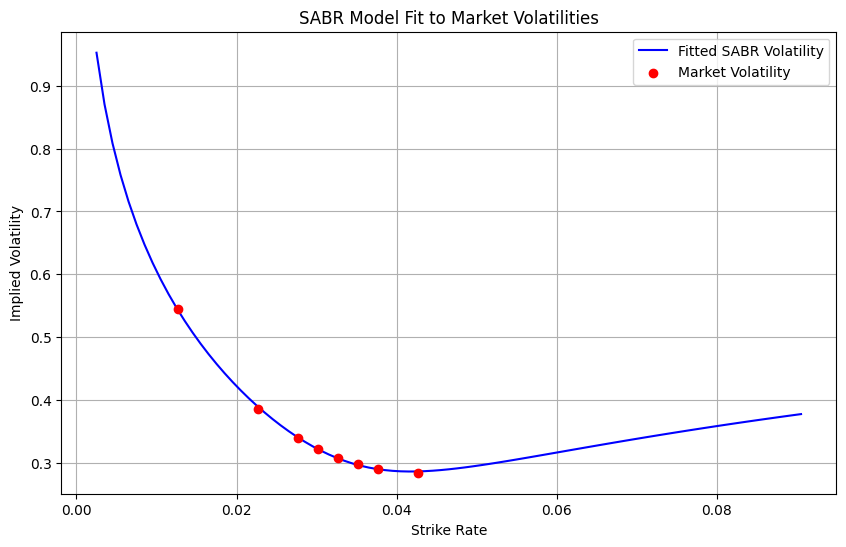

In [44]:
grid_strikes = np.arange(0.0025, 0.09 + 0.0010, 0.0010)
fitted_vols = sabr(BETA, nu_opt, rho_opt, alpha_opt, F, grid_strikes, T)

plt.figure(figsize=(10, 6))
plt.plot(grid_strikes, fitted_vols, label='Fitted SABR Volatility', color='blue')
plt.scatter(strikes, market_vols, label='Market Volatility', color='red', zorder=5)
plt.title('SABR Model Fit to Market Volatilities')
plt.xlabel('Strike Rate')
plt.ylabel('Implied Volatility')
plt.legend()
plt.grid()
plt.show()

### 1.3.
Suppose we want to price the `1y4y` swaption but with a far out-of-the-money strike of `5%`. 

* Use the SABR vol at this strike to price the swaption.

(Note that this strike is far outside the range for which we have market quotes, and even if we do have quotes, they likely are not liquid on a given day.)


In [56]:
far_out_of_money_strike = 0.05
far_out_of_money_vol = sabr(BETA, nu_opt, rho_opt, alpha_opt, F, far_out_of_money_strike, T)
print(f"Fitted SABR volatility for far OTM strike {far_out_of_money_strike:.4f}: {far_out_of_money_vol:.4f}")

d_1 = (np.log(F / far_out_of_money_strike) + 0.5 * far_out_of_money_vol**2 * T) / (far_out_of_money_vol * np.sqrt(T))
d_2 = d_1 - far_out_of_money_vol * np.sqrt(T)
from scipy.stats import norm
call_price = annuity * (F * norm.cdf(d_1) - far_out_of_money_strike * norm.cdf(d_2))
print(f"Price of far OTM call option: {call_price:.6f}")

Fitted SABR volatility for far OTM strike 0.0500: 0.2953
Price of far OTM call option: 0.001439


### 1.4.

Use the ATM implied volatility to fit $\alpha$, (sometimes denoted $\sigma_0$.) That is, for any choice of $(\rho,\nu)$, solve a quadratic equation to get $\alpha$ as a function of those two parameters, along with $\beta$, which is at its selected (not estimated) value.

Recall that we have a simple relationship between ATM vol and $\alpha$.

$$\sigma_\text{ATM} = \alpha\frac{B}{F^{1-\beta}}$$
where $B$ is defined in the discussion note. It is a quadratic expression of $\alpha$ along with $(\beta,\rho,\nu)$.

This decouples the optimization. We solve for $(\rho,\nu)$ and $\alpha$ as a function of the other two parameters.

Consider using the function `sabrATM` in `cmds/volskew.py`.


# 2. SABR and Risk Management


Consider how an **increase** of `50bps` in the underlying rate impacts the price of the `1y4y` ATM swaption.

Here, we are assuming that
* the rate change will impact the forward swap rate directly, one-for-one with other rates.
* the shift happens one week after the original quote date.

Of course, in reality, a rate change
* may price in early to some degree if it is expected
* may not impact the forward swap rate one-for-one. We would need to model how the discount curve changes and what that change (level, slope, curvature?) would do to the forward swap rate.


### 2.1

Use Black's equation to re-price the `1y4y` swaption with
* the same ATM volatility
* an underlying (forward swap) rate `increased` `50bps`.
* the same time-to-maturities. (We should decrease these all by 1/365, but we focus here on the delta effects rather than the theta. And it would be a small impact anyone.)

Report 
* the new price
* the change in price divided by `50bps`, (a numerical delta.)


### 2.2

Now, we consider how the volatility may change with the underlying shift `up` of `50bps`.

Using the same SABR parameters from `2.1`, and the strike grid from `2.2`, plot the new SABR curve accounting for the underlying rate shifting `up` `50bps`.


### 2.3

Calculate the new volatility specifically for the pre-shift ATM strike.

Use this in Black's formula similar to `3.1`, where the only change is the volatility now reflects the shift in the underlying (not the strike).

Report
* the new price
* the change in price divided by `50bps`


### 2.4

How much different is the (dynamic) delta which accounts for the shift in volatility from the (static) delta in `3.1`?


In [66]:
print(f"F value: {F}")
print(f"F type: {type(F)}")
print(f"strikes: {strikes}")
print(f"T: {T}")
print(f"market_vols: {market_vols}")
print(f"\nOptimization result:")
print(f"nu={nu_opt:.6f}, rho={rho_opt:.6f}, alpha={alpha_opt:.6f}")
print(f"Final error: {result.fun:.6f}")

F value: 0.03269770231881184
F type: <class 'numpy.float64'>
strikes: [0.0126977 0.0226977 0.0276977 0.0301977 0.0326977 0.0351977 0.0376977
 0.0426977]
T: 1
market_vols: [np.float64(0.54405) np.float64(0.38565) np.float64(0.33925)
 np.float64(0.32195) np.float64(0.30829999999999996) np.float64(0.29805)
 np.float64(0.29095) np.float64(0.2843)]

Optimization result:
nu=0.747675, rho=-0.329509, alpha=0.127288
Final error: 0.000025
